# Классификация: SI > 8

SI > 8 — это фармакологический порог: соединения с таким SI считаются перспективными для разработки препарата.

Ожидаю что классов может быть неровно — надо сначала проверить.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier


In [17]:
df = pd.read_excel('/content/Данные_для_курсовои_Классическое_МО (1).xlsx', index_col=0)

targets = ['IC50, mM', 'CC50, mM', 'SI']
features = [c for c in df.columns if c not in targets]
X = df[features]

y = (df['SI'] > 8).astype(int)
print(y.value_counts())
print(f'Доля класса 1 (SI > 8): {y.mean():.2%}')

SI
0    644
1    357
Name: count, dtype: int64
Доля класса 1 (SI > 8): 35.66%


Посмотрим на распределение SI чтобы понять где находится порог 8.

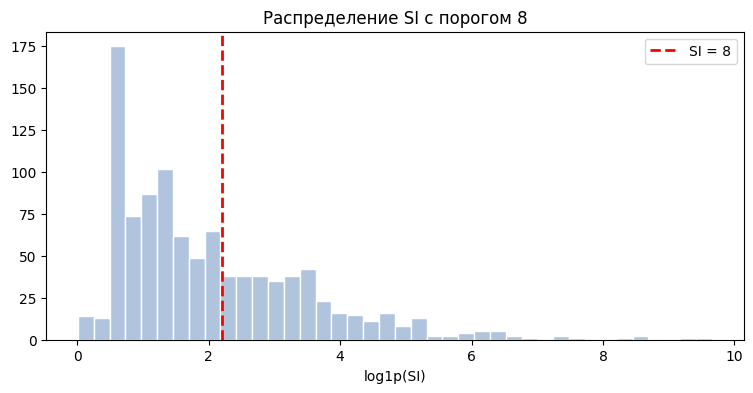

Медиана SI: 3.85
SI > 8: 357 объектов


In [18]:
plt.figure(figsize=(9, 4))
plt.hist(np.log1p(df['SI']), bins=40, color='lightsteelblue', edgecolor='white')
plt.axvline(np.log1p(8), color='red', linestyle='--', linewidth=2, label='SI = 8')
plt.xlabel('log1p(SI)')
plt.title('Распределение SI с порогом 8')
plt.legend()
plt.show()

print(f'Медиана SI: {df["SI"].median():.2f}')
print(f'SI > 8: {(df["SI"] > 8).sum()} объектов')

In [22]:
X = X.fillna(0)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]} ({y_train.mean():.1%} класс 1)')
print(f'Test:  {X_test.shape[0]} ({y_test.mean():.1%} класс 1)')

Train: 800 (35.6% класс 1)
Test:  201 (35.8% класс 1)


Если классов неровно — accuracy будет обманчива. Буду смотреть на ROC-AUC и F1.

In [24]:
results = {}

# Logistic Regression — baseline
gs_lr = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))]),
    {'model__C': [0.01, 0.1, 1, 10]},
    cv=5, scoring='roc_auc', n_jobs=-1)
gs_lr.fit(X_train, y_train)
prob_lr = gs_lr.predict_proba(X_test)[:, 1]
pred_lr = gs_lr.predict(X_test)
results['Logistic Regression'] = {
    'ROC-AUC': roc_auc_score(y_test, prob_lr),
    'F1': f1_score(y_test, pred_lr)
}
print(f'LR: AUC={results["Logistic Regression"]["ROC-AUC"]:.3f}')

LR: AUC=0.673


In [25]:
# Decision Tree
gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    {'max_depth': [3, 5, 8, None], 'min_samples_leaf': [1, 5]},
    cv=5, scoring='roc_auc', n_jobs=-1)
gs_dt.fit(X_train, y_train)
prob_dt = gs_dt.predict_proba(X_test)[:, 1]
pred_dt = gs_dt.predict(X_test)
results['Decision Tree'] = {
    'ROC-AUC': roc_auc_score(y_test, prob_dt),
    'F1': f1_score(y_test, pred_dt)
}
print(f'DT: AUC={results["Decision Tree"]["ROC-AUC"]:.3f}, best_depth={gs_dt.best_params_}')

DT: AUC=0.687, best_depth={'max_depth': None, 'min_samples_leaf': 5}


In [26]:
# Random Forest
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    {'n_estimators': [100, 200], 'max_depth': [None, 10], 'min_samples_leaf': [1, 3]},
    cv=5, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X_train, y_train)
prob_rf = gs_rf.predict_proba(X_test)[:, 1]
pred_rf = gs_rf.predict(X_test)
results['Random Forest'] = {
    'ROC-AUC': roc_auc_score(y_test, prob_rf),
    'F1': f1_score(y_test, pred_rf)
}
print(f'RF: AUC={results["Random Forest"]["ROC-AUC"]:.3f}')

RF: AUC=0.755


In [27]:
# Gradient Boosting
gs_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
    cv=5, scoring='roc_auc', n_jobs=-1)
gs_gb.fit(X_train, y_train)
prob_gb = gs_gb.predict_proba(X_test)[:, 1]
pred_gb = gs_gb.predict(X_test)
results['Gradient Boosting'] = {
    'ROC-AUC': roc_auc_score(y_test, prob_gb),
    'F1': f1_score(y_test, pred_gb)
}
print(f'GB: AUC={results["Gradient Boosting"]["ROC-AUC"]:.3f}')

GB: AUC=0.724


## Сравнение моделей

                     ROC-AUC      F1
Random Forest         0.7547  0.5588
Gradient Boosting     0.7241  0.5484
Decision Tree         0.6870  0.5772
Logistic Regression   0.6729  0.5570


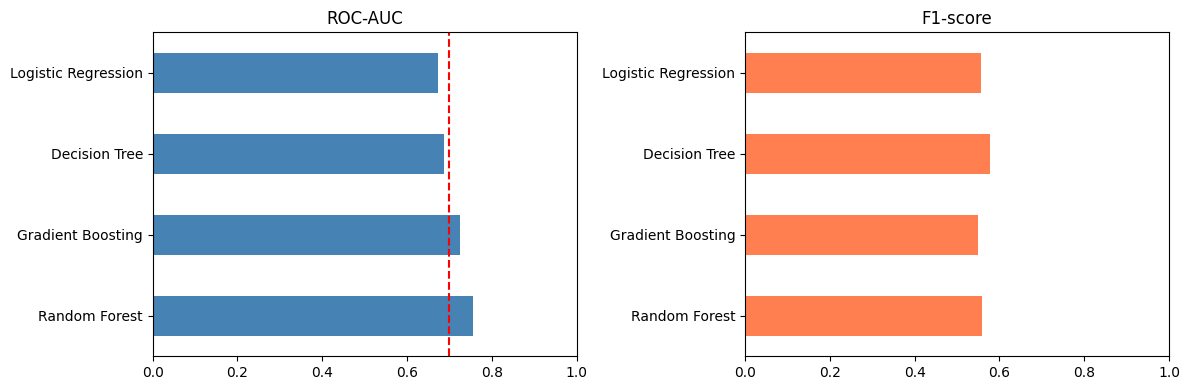

In [28]:
res_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print(res_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
res_df['ROC-AUC'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(0.7, color='red', linestyle='--')
axes[0].set_title('ROC-AUC')
axes[0].set_xlim(0, 1)

res_df['F1'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('F1-score')
axes[1].set_xlim(0, 1)
plt.tight_layout()
plt.show()

## ROC-кривые

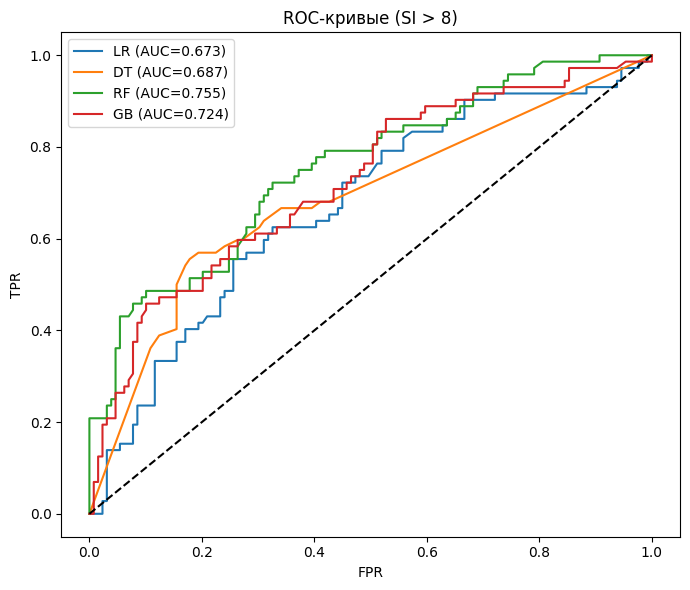

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, probs in [('LR', prob_lr), ('DT', prob_dt), ('RF', prob_rf), ('GB', prob_gb)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC-кривые (SI > 8)')
ax.legend()
plt.tight_layout()
plt.show()

Random Forest показал наилучший результат (AUC = 0.755), его кривая заметно выше остальных. Gradient Boosting на втором месте (AUC = 0.724). Decision Tree (AUC = 0.687) и Logistic Regression (AUC = 0.673) справились хуже. В целом результаты ниже чем в задачах CC50 и SI > медианы — это ожидаемо, так как SI > 8 имеет дисбаланс классов (36% против 64%).

## Confusion matrix лучшей модели

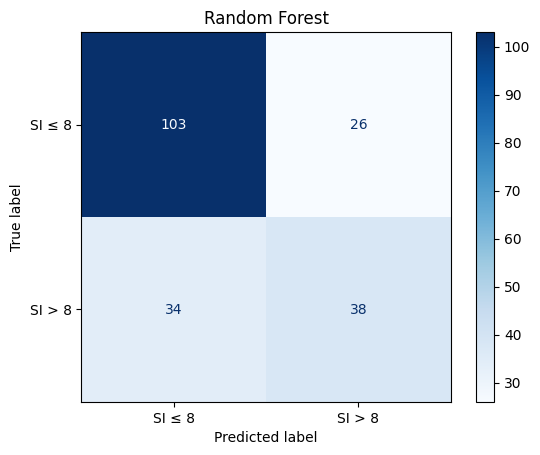

              precision    recall  f1-score   support

      SI ≤ 8       0.75      0.80      0.77       129
      SI > 8       0.59      0.53      0.56        72

    accuracy                           0.70       201
   macro avg       0.67      0.66      0.67       201
weighted avg       0.70      0.70      0.70       201



In [30]:
best = res_df.index[0]
pred_map = {'Logistic Regression': pred_lr, 'Decision Tree': pred_dt,
            'Random Forest': pred_rf, 'Gradient Boosting': pred_gb}
best_pred = pred_map[best]

cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(cm, display_labels=['SI ≤ 8', 'SI > 8']).plot(cmap='Blues')
plt.title(f'{best}')
plt.show()

print(classification_report(y_test, best_pred, target_names=['SI ≤ 8', 'SI > 8']))

Random Forest правильно классифицировал 103+38=141 из 201 объектов (accuracy = 70%). Модель значительно лучше распознаёт соединения с SI ≤ 8 (recall = 0.80) чем SI > 8 (recall = 0.53) — это следствие дисбаланса классов (129 против 72). Модель пропускает почти половину активных соединений с SI > 8 (34 ошибки) — в реальной задаче поиска лекарств это критично, так как мы теряем потенциально эффективные соединения.

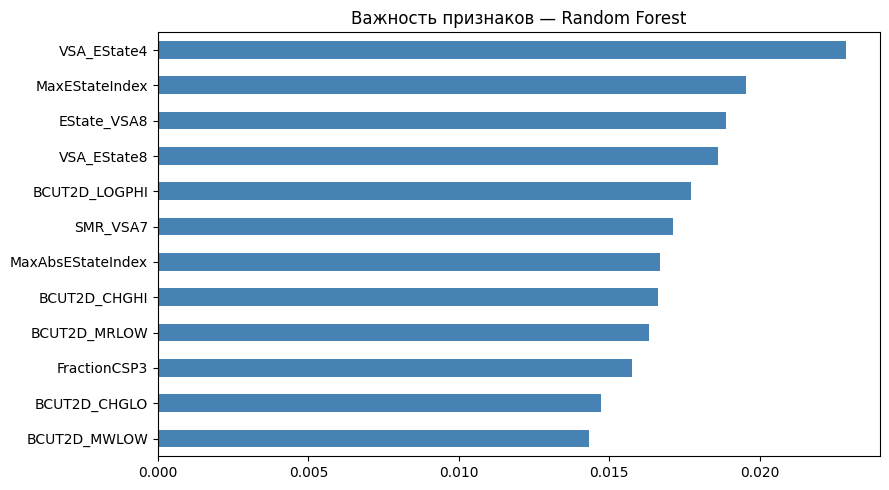

In [31]:
# важность признаков
if best in ['Random Forest', 'Gradient Boosting']:
    m = gs_rf.best_estimator_ if best == 'Random Forest' else gs_gb.best_estimator_
    s = pd.Series(m.feature_importances_, index=features).sort_values(ascending=False).head(12)
    s[::-1].plot(kind='barh', figsize=(9, 5), color='steelblue')
    plt.title(f'Важность признаков — {best}')
    plt.tight_layout()
    plt.show()

## Вывод

Лучшей моделью для классификации SI > 8 оказался Random Forest (ROC-AUC = 0.755, F1 = 0.559). Gradient Boosting на втором месте (ROC-AUC = 0.724, F1 = 0.548). Decision Tree и Logistic Regression показали слабый результат (ROC-AUC = 0.687 и 0.673). В целом все метрики ниже чем в задачах с медианным порогом — это объясняется дисбалансом классов (36% vs 64%)